mean estimate: 0.7
mean estimate: 0.7083333333333334
mean estimate: 0.7461129501454518
total reward earned:  7447.0
overall win rate:  0.7447
num times selected each bandit:  [10, 24, 9969]


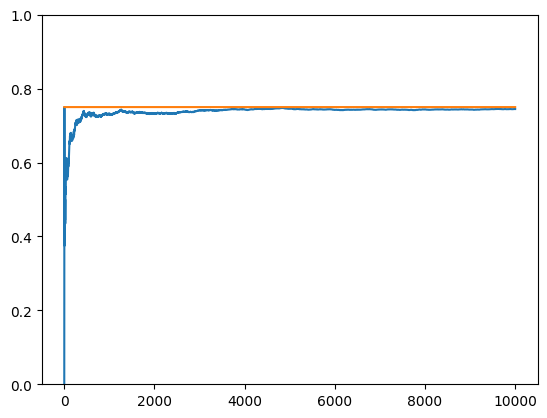

In [5]:
import matplotlib.pyplot as plt
import numpy as np

NUM_TRIALS = 10000
EPS = 0.1
BANDIT_PROBABILITIES = [0.2, 0.5, 0.75]

class Bandit:
  def __init__(self, p):
    # p: the win rate
    self.p = p
    self.p_estimate = 5
    self.N = 1

  def pull(self):
    # draw a 1 with probability p
    return np.random.random() < self.p

  def update_estimate(self, x):
    self.N += 1
    # Beräkna löpande medelvärde
    self.p_estimate = ((self.N -1)*self.p_estimate + x) / self.N

def experiment():
  bandits = [Bandit(p) for p in BANDIT_PROBABILITIES]
  rewards = np.zeros(NUM_TRIALS)

  for i in range(NUM_TRIALS):
    # Epsilon-greedy logik
    j = np.argmax([b.p_estimate for b in bandits])

    # Dra i spaken
    x = bandits[j].pull()

    # Uppdatera banditen med resultatet
    bandits[j].update_estimate(x)

    # Spara resultatet i vår logg
    rewards[i] = x

  # Printa resultat
  for b in bandits:
    print("mean estimate:", b.p_estimate)

  print("total reward earned: ", rewards.sum())
  print("overall win rate: ", rewards.sum() / NUM_TRIALS)
  print("num times selected each bandit: ", [b.N for b in bandits])

  # Plotga resultat
  cumulative_rewards = np.cumsum(rewards)
  win_rates = cumulative_rewards / (np.arange(NUM_TRIALS) + 1)
  plt.ylim([0, 1])
  plt.plot(win_rates)
  plt.plot(np.ones(NUM_TRIALS) * np.max(BANDIT_PROBABILITIES))
  plt.show()

# VIKTIGT: Du måste anropa funktionen för att den ska köra!
if __name__ == "__main__":
  experiment()